# **Milestone 1**

### Goals

- Assess **data loading pipeline** fully operational.
- Fetching a batch of images and their corresponding tags to confirm **correct tensor shapes and data formatting** before moving into the modeling phase.

### Contents
- **Exploratory data analysis (EDA)**: iterare through a batch of images to visually inspect data integrity (e.g.: crops).
- **Preprocessing**: structuring data into batches of 32. Image tensors are shaped to [32, 3, 224, 224], representing 3 color channels (RGB) and a standard 224x224 pixel resolution. The tags (labels) are loaded as 1D tensors of size 32. The images have been normalized.

### Results
- **Outputs & Metrics**: the output verifies that the tensor dimensions perfectly align with standard requirements (Batch | Channels | Height | Width).
- **Visualizations**: comparison between the static pixel input spectrogram and the accumulated spike activity map over T=10 time steps. High energy regions and sharp intensity gradients in the spectrogram cause maximal firing rates (yellow regions, reaching 10 spikes), while low-energy background regions remain silent (black regions, 0 spikes). This demonstrates that the initial convolutional layer maps pixels into temporal spike trains, while preserving the structural morphology of the gravitational-wave glitch.

In [1]:
%pip install torch
%pip install snntorch
%pip install torchvision

import torch
import torch.nn as nn
import snntorch as snn

import matplotlib.pyplot as plt
import numpy as np
import os

from dataloader import train_dataloader, val_dataloader, test_dataloader

plt.style.use('seaborn-v0_8-whitegrid')

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\devam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\devam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\devam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
images, tags = next(iter(train_dataloader))
print(f"Milestone M1: dataloader ready")
print(f"Images dimensions (Batch | Channels | Height | Width) : {images.shape}")
print(f"Tags dimensions: {tags.shape}")

Milestone M1: dataloader ready
Images dimensions (Batch | Channels | Height | Width) : torch.Size([32, 3, 224, 224])
Tags dimensions: torch.Size([32])


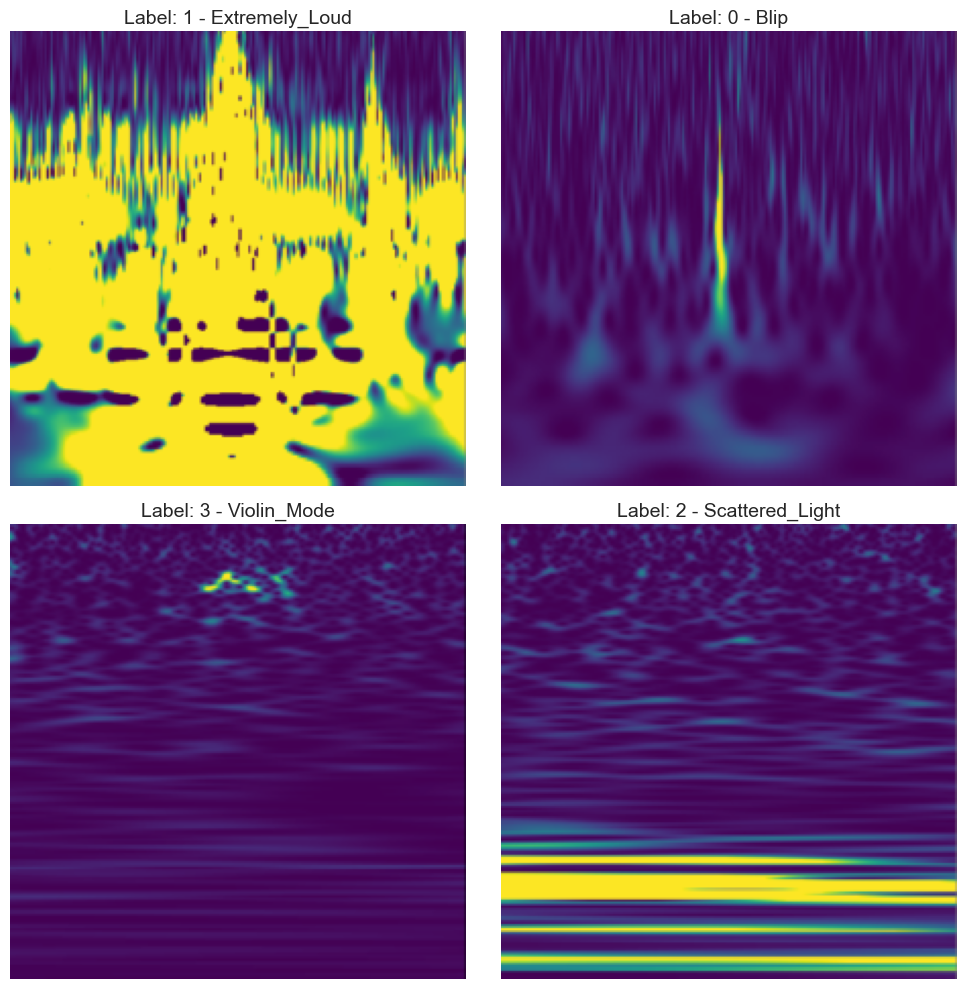

In [7]:
# Plot
class_names = {
    0: "Blip",
    1: "Extremely_Loud",
    2: "Scattered_Light",
    3: "Violin_Mode"
}

fig, axes = plt.subplots(2, 2, figsize = (10, 10))
axes = axes.flatten()

found_classes = []
plot_idx = 0

# Search thru whole batch
for i in range(len(tags)):
    curr_label = tags[i].item()
    if curr_label not in found_classes and plot_idx < 4:
        found_classes.append(curr_label)

        img_to_plot = images[i].permute(1, 2, 0).numpy()

        # Invert normalization to address matplotlib
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_to_plot = std * img_to_plot + mean
        
        img_to_plot = np.clip(img_to_plot, 0, 1)

        axes[plot_idx].imshow(img_to_plot)

        name_class = class_names.get(curr_label, "Unknown")

        axes[plot_idx].set_title(f"Label: {curr_label} - {name_class}", fontsize=14)
        axes[plot_idx].axis('off')

        plot_idx += 1

plt.tight_layout()
plt.show()

In [17]:
'''
Direct coding simulation & raster plot
'''
# Take first image and use unsqueeze to create a dimention to have batch = 1

img_sample = images[0].unsqueeze(0)
tag_sample = tags[0].item()

num_steps = 10
beta = 0.95 # decaying rate of the neuron

conv1 = nn.Conv2d(in_channels = 3, out_channels = 16, kernel_size = 5, stride = 2, padding = 2)
lif1 = snn.Leaky(beta=beta)

membrane = lif1.init_leaky()    # initialize membrane potential

spike_rec = []  # list spike recordings

for step in range(num_steps):
    cur = conv1(img_sample) * 3.5             # image to current
    spike, membrane = lif1(cur, membrane)   # current to spike
    spike_rec.append(spike)

spike_tensor = torch.stack(spike_rec, dim=0)

print(f"Spike tensors' shape: {spike_tensor.shape} -> [Time, Batch, Channels, Height, Witdh]")


Spike tensors' shape: torch.Size([10, 1, 16, 112, 112]) -> [Time, Batch, Channels, Height, Witdh]


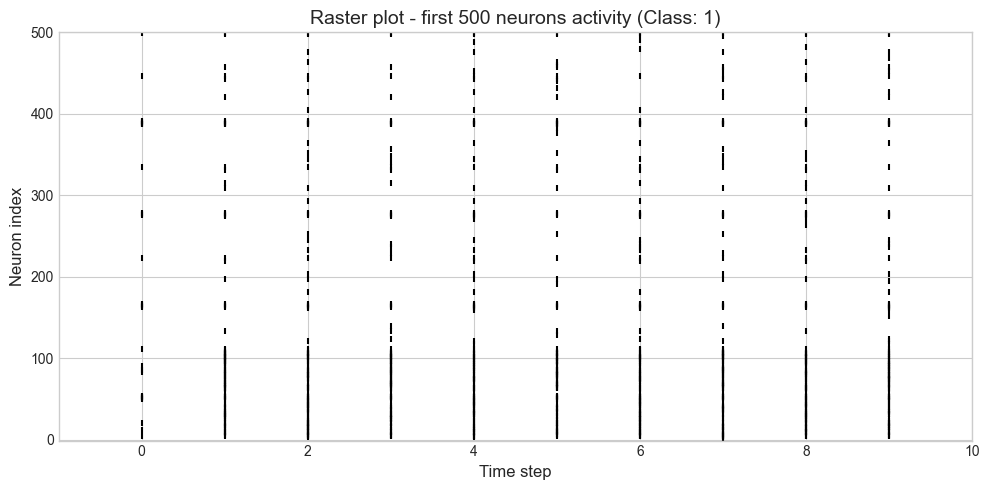

In [18]:
'''
Raster plots
'''
flattened_spike_tensor = spike_tensor.view(num_steps, -1)  # from [10, 1, 16, 112, 112] to [10, 200704]
spikes_sample = flattened_spike_tensor[:, :500]

# Coordinates (X=time, Y=neuron) in which a spike occurred (== 1)
time_steps, neuron_indices = torch.where(spikes_sample == 1)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(time_steps.numpy(), neuron_indices.numpy(), marker='|', color='black', s=20)

ax.set_title(f"Raster plot - first 500 neurons activity (Class: {tag_sample})", fontsize=14)
ax.set_xlabel("Time step", fontsize=12)
ax.set_ylabel("Neuron index", fontsize=12)
ax.set_xlim(-1, num_steps)
ax.set_ylim(-1, 500)

plt.tight_layout()
plt.show()

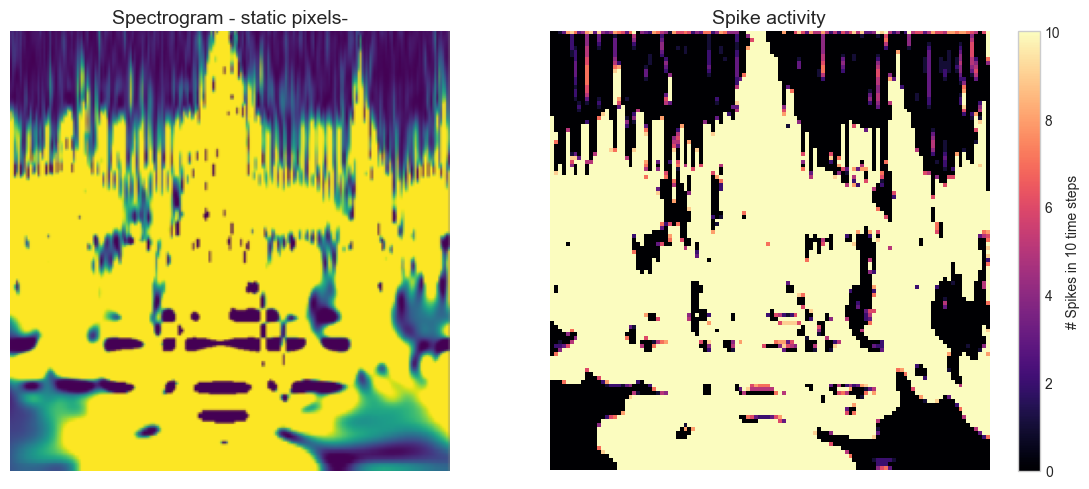

In [20]:
'''
Static spectrograms pixels vs Spike activity
'''
spike_counts = spike_tensor.sum(dim=0)  # sum spikes over time axis

snn_feature_map = spike_counts[0, 0, :, :].detach().numpy() # eliminate batch and channel dimensions to have a 2D matrix

original_spectrogram = img_sample[0].permute(1, 2, 0).numpy()

# Denoramalization as before
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
original_spectrogram = std * original_spectrogram + mean
original_spectrogram = np.clip(original_spectrogram, 0, 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# plot original spectrogram
ax1.imshow(original_spectrogram)
ax1.set_title("Spectrogram - static pixels-", fontsize=14)
ax1.axis('off')

# plot accumulated spikes -> spike activity
cax = ax2.imshow(snn_feature_map, cmap='magma')
ax2.set_title("Spike activity", fontsize=14)
ax2.axis('off')

fig.colorbar(cax, ax=ax2, label='# Spikes in 10 time steps')

plt.tight_layout()
plt.show()